In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data
import seaborn as sns

from ISLP.models import ModelSpec as MS
import statsmodels.api as sm

from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
data = load_data("Boston")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


<Axes: >

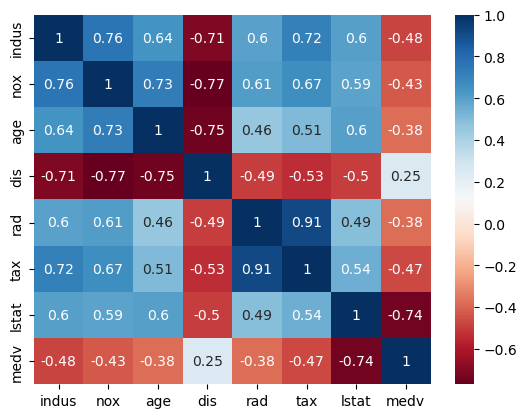

In [3]:
corr = data.corr(numeric_only=True)
cols = corr.columns[
    (corr.abs() > 0.7 ).sum(axis=1) > 1
]

corr_filtered = corr.loc[cols, cols]
sns.heatmap(corr_filtered, annot=True, cmap="RdBu")


In [4]:
data.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [5]:
y = data["dis"]
X = data["nox"]
y.shape

(506,)

In [6]:
np.hstack?

Signature:       np.hstack(tup, *, dtype=None, casting='same_kind')
Call signature:  np.hstack(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function hstack at 0x000002326DEEFF60>
File:            c:\users\pytla\anaconda3\lib\site-packages\numpy\_core\shape_base.py
Docstring:      
Stack arrays in sequence horizontally (column wise).

This is equivalent to concatenation along the second axis, except for 1-D
arrays where it concatenates along the first axis. Rebuilds arrays divided
by `hsplit`.

This function makes most sense for arrays with up to 3 dimensions. For
instance, for pixel-data with a height (first axis), width (second axis),
and r/g/b channels (third axis). The functions `concatenate`, `stack` and
`block` provide more general stacking and concatenation operations.

Parameters
----------
tup : sequence of ndarrays
    The arrays must have the same shape along all but the second axis,
    except 1-D arrays which can be any length.

dtype : str o

In [7]:
# def poly(x, degree, include_bias=True):
#     x = np.asarray(x).reshape(-1,1)

#     start = 0 if include_bias else 1

#     powers = range(start, degree+1)

#     X_poly = np.hstack([x ** p for p in powers])

#     return X_poly

In [8]:
class Poly:
    def __init__(self, col, degree):
        self.col = col
        self.degree = degree

    def fit(self, X):
        return self

    def transform(self, X):
        x = X[self.col].to_numpy().reshape(-1, 1)
        return np.hstack([x ** d for d in range(1, self.degree + 1)])


I have a task to use Poly and ModelSpec functions from ISLP.models but I will create it on my own.

In [9]:
MS?

Init signature:
MS(
    terms=[],
    intercept=True,
    categorical_features=None,
    categorical_encoders={},
)
Docstring:     
Parameters
----------

terms : sequence (optional)

    Sequence of sets whose
    elements are columns of *X* when fit.
    For :py:class:`pd.DataFrame` these can be column
    names.

intercept : bool (optional)

    Include a column for intercept?

categorical_features : array-like of {bool, int} of shape (n_features) 
        or shape (n_categorical_features,), default=None.

    Indicates the categorical features. Will be ignored if *X* is a :py:class:`pd.DataFrame`
    or :py:class:`pd.Series`.

    - None : no feature will be considered categorical for :py:class:`np.ndarray`.
    - boolean array-like : boolean mask indicating categorical features.
    - integer array-like : integer indices indicating categorical
      features.

categorical_encoders : dict

    Dictionary whose keys are elements of *terms* that represent
    **categorical variables*

In [10]:
class MyModelSpec:
    def __init__(self, terms):
        self.terms = terms
        
    def fit(self, X):
        self.columns_ = []

        for term in self.terms:
            if isinstance(term, str):
                self.columns_.append(term)
            elif hasattr(term, "fit"):
                term.fit(X)
        return self

    def transform(self, X):
        blocks = []

        for term in self.terms:
            if isinstance(term, str):
                blocks.append(X[[term]].to_numpy())

            else:
                blocks.append(term.transform(X))
        return np.hstack(blocks)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [11]:
data = data[["nox"]]
data.head()

,nox
0,0.538
1,0.469
2,0.469
3,0.458
4,0.458


In [12]:
X
y

0      4.0900
1      4.9671
2      4.9671
3      6.0622
4      6.0622
        ...  
501    2.4786
502    2.2875
503    2.1675
504    2.3889
505    2.5050
Name: dis, Length: 506, dtype: float64

In [13]:
x_grid = np.linspace(data["nox"].min(), data["nox"].max(), 200)
grid_df = pd.DataFrame({
    "nox": x_grid
})

spec = MyModelSpec([Poly("nox", 2)])
X_train = spec.fit_transform(data)
y_train = y
model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

X_grid = spec.transform(grid_df)
X_grid_const = sm.add_constant(X_grid, has_constant="add")
y_pred = model.predict(X_grid_const)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    dis   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     700.1
Date:                Mon, 15 Dec 2025   Prob (F-statistic):          4.46e-146
Time:                        12:47:14   Log-Likelihood:                -757.60
No. Observations:                 506   AIC:                             1521.
Df Residuals:                     503   BIC:                             1534.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         28.7435      1.065     26.987      0.0

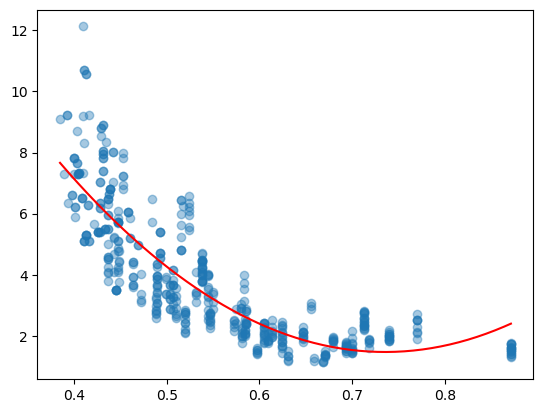

In [14]:
plt.scatter(data["nox"], y, alpha=0.4)
plt.plot(x_grid, y_pred, color="red")
plt.show()

Looks quite reasonable.

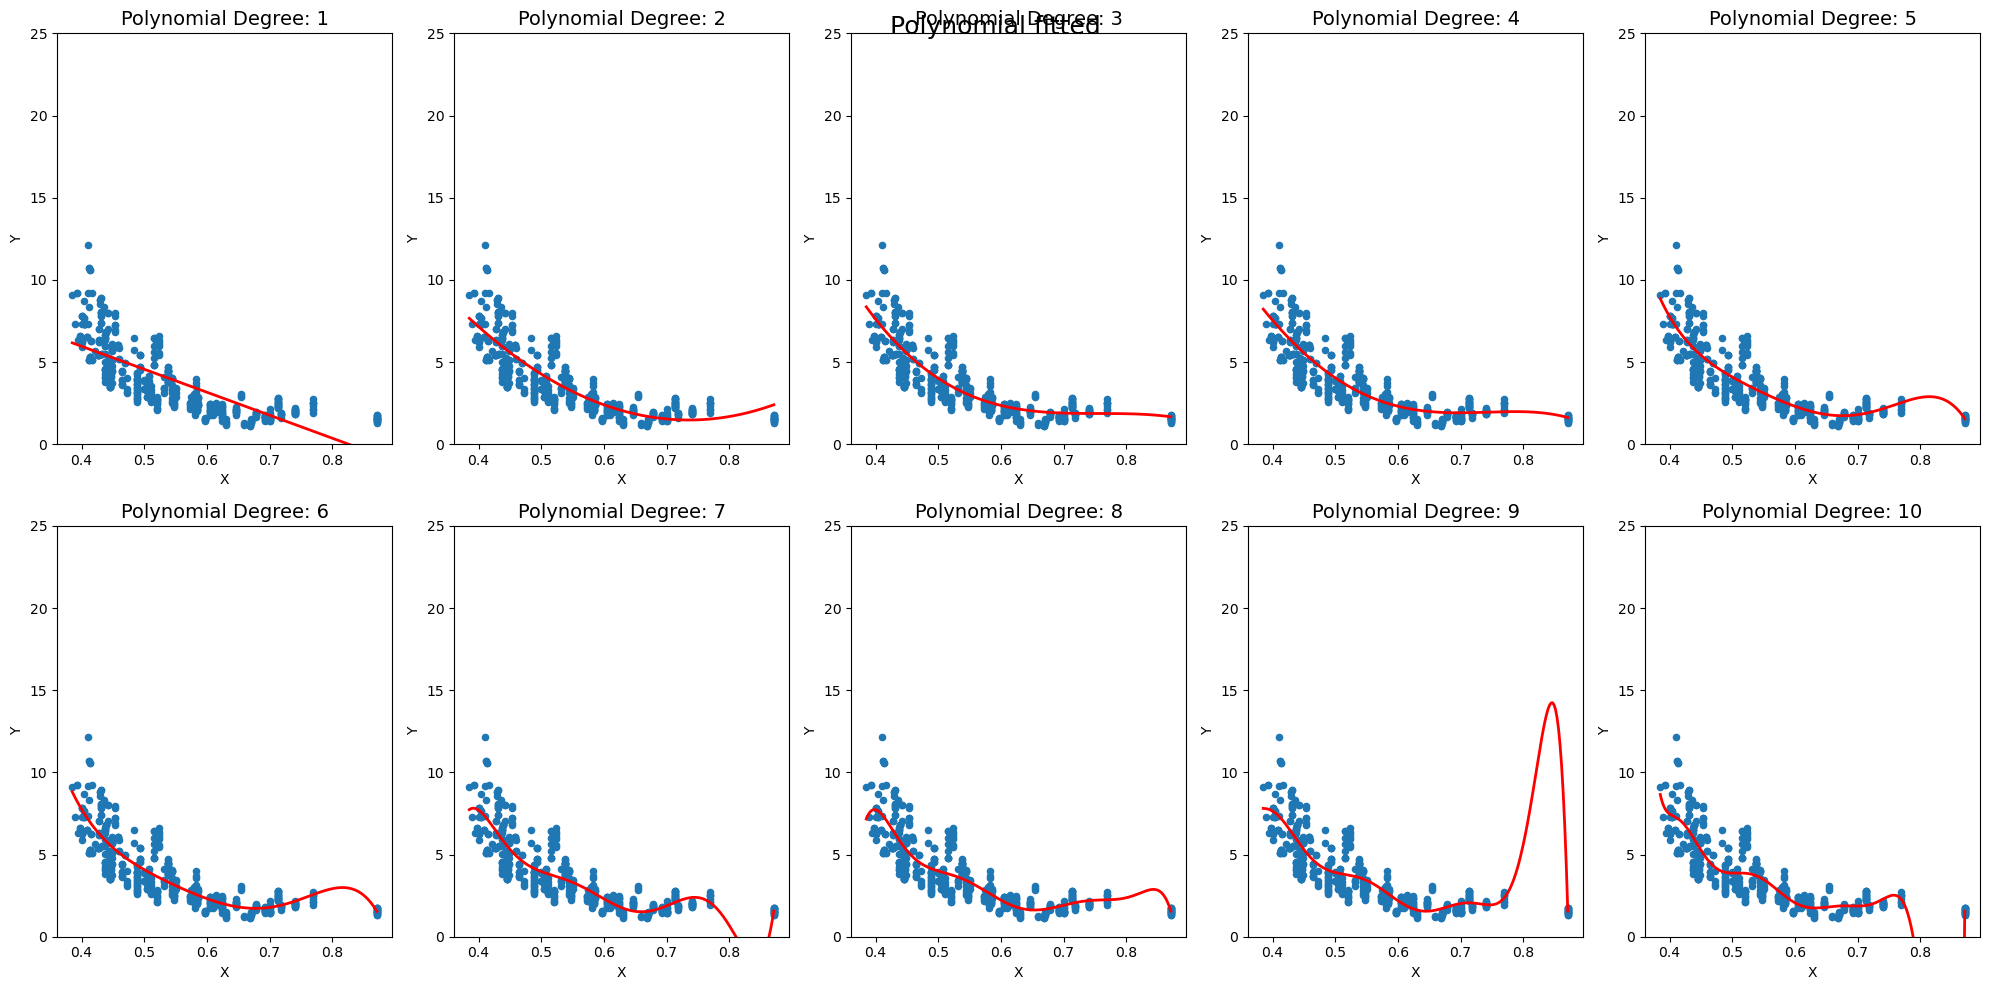

In [15]:
degrees = range(1,11)
results = {}

x_grid = np.linspace(data["nox"].min(), data["nox"].max(), 200)

grid_df = pd.DataFrame({
        "nox": x_grid,
    })

y_train = y

kf = KFold(n_splits=5, shuffle=True)

plt.figure(figsize=(20, 10))

for i, degree in enumerate(degrees):
    
    spec = MyModelSpec([Poly("nox", degree)])
    X_train = spec.fit_transform(data)
    X_train_const = sm.add_constant(X_train, has_constant="add")
    model = sm.OLS(y_train, sm.add_constant(X_train_const)).fit()

    mse_list = []

    for train_idx, test_idx in kf.split(X_train):
        X_train_fold, X_test_fold = X_train[train_idx], X_train[test_idx]
        y_train_fold, y_test_fold = y_train[train_idx], y_train[test_idx]

        model_fold = sm.OLS(y_train_fold, sm.add_constant(X_train_fold, has_constant="add")).fit()
        y_test_pred = model_fold.predict(sm.add_constant(X_test_fold, has_constant="add"))

        mse_list.append(np.mean((y_test_fold - y_test_pred)**2))

    results[degree] = np.mean(mse_list)
    
    
    X_grid = spec.transform(grid_df)
    X_grid_const = sm.add_constant(X_grid, has_constant="add")
    y_grid_pred = model.predict(X_grid_const)
        

    
    ax = plt.subplot(2, 5, i + 1)
    plt.scatter(X, y_train, s=20, label='Real data')
    
    plt.plot(x_grid, y_grid_pred, color='red', 
             label=f'Degree {degree}', linewidth=2)
    
    ax.set_title(f'Polynomial Degree: {degree}', fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.ylim(0, 25)

plt.tight_layout()
plt.suptitle('Polynomial fitted', fontsize=18)
plt.show()



In [16]:
min_key = min(results, key=results.get)
min_val = results[min_key]
print("Lowest MSE is in: ", min_key, "with the value of:", min_val)


Lowest MSE is in:  10 with the value of: 1.0504142780949757


As we can see MSE is not a good way choose optimal polynomial degree here.

To choose the most accurate polynomial degreee I will pick Lasso for weakening Bigger coeffs.

In [17]:
class PolyTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, poly_spec):
        self.spec = poly_spec 
        
    def fit(self, X, y=None):
        self.spec.fit_transform(X)
        return self
    
    def transform(self, X):
        return self.spec.transform(X).values

In [23]:
alpha = 0.1 

results={}

kf = KFold(n_splits=5, shuffle=True)

plt.figure(figsize=(20, 10))

y_data_np = y.values if hasattr(y, "values") else y
y_data_np = np.asarray(y_data_np, dtype=np.float64)

for i, degree in enumerate(degrees):
    
    spec = MyModelSpec([Poly("nox", degree)])
    X_train = spec.fit_transform(data).astype(np.float64)     
    
    pipeline = Pipeline([
        ('poly', PolyTransformer(spec)),
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=10000))
    ])
    
    mse_list = []

    for train_idx, test_idx in kf.split(X_train):
        X_train_fold, X_test_fold = X_train[train_idx], X_train[test_idx]
        y_train_fold, y_test_fold = y_data_np[train_idx], y_data_np[test_idx]

        pipeline.fit(X_train_fold, y_train_fold)
        y_test_pred = pipeline.predict(X_test_fold)

        mse_list.append(np.mean((y_test_fold - y_test_pred)**2))

    results[degree] = np.mean(mse_list)
    
    pipeline.fit(X_train, y_train)
    
    X_grid = spec.transform(grid_df)
    y_grid_pred = pipeline.predict(X_grid)
        
    ax = plt.subplot(2, 5, i + 1)
    plt.scatter(X, y_train, s=20, label='Real data')
    plt.plot(x_grid, y_grid_pred, color='red', 
             label=f'Degree {degree}', linewidth=2)
    
    ax.set_title(f'Polynomial Degree: {degree}', fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.ylim(0, 25)

plt.tight_layout()
plt.suptitle('Polynomial fitted with Lasso', fontsize=18)
plt.show()

best_degree = min(results, key=results.get)
print(f"Optymalny stopień polinomu: {best_degree}, Średnie MSE (5-fold CV) = {results[best_degree]:.4f}")


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

<Figure size 2000x1000 with 0 Axes>